In [1]:
import logging 
logging.basicConfig(level=logging.CRITICAL)

In [54]:
import logging
import typing
import numpy as np
import scipy.optimize

import numpy as np
from melatonin.detectors.base import BaseDetector
from melatonin.detectors.heraklion import HeraklionDetector, HeraklionParameters
from melatonin.detectors.pra import PRADetector, PRAParameters
from melatonin.microphones import AnechoicRoomMicrophones
from melatonin.parameters import CommonParameters
from melatonin.sources import PositionGenerator, SignalGenerator


def wrap_angle(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi


def align_predictions_rad(
    real_doas: np.ndarray, predicted_doas: np.ndarray
) -> np.ndarray:
    """Align predictions to grounds considering circular logic.

    Consider that a detector will not return the estimated DoAs in the same order
    that the ground DoAs are because the algorithm will only see microphone signals,
    which are a linear sum of the delayed and attenuated source signals and therefore
    has no order.


    This function will permutate the predictions in order to find the best match for
    the grounds.

    Parameters
    ----------
    real_doas : np.ndarray
        Real DoAs, in radians.
    predicted_doas : np.ndarray
        Estimated DoAs, in radians.

    Examples
    -----
    Consider for example the case where grounds is [179., 359] and the predictions are
    [0, 180]. One can see that the algorithm is pretty accurate with a MAE of 1,
    but
    1) the predictions themselves do not match the grounds
    2) we must consider the circular nature of the degrees, as the estimated angle 0
      corresponds to the true angle 359.
    The function will behave as follows:
    >>> real_doas_d = np.array([179, 359])
    >>> predicted_doas_d = np.array([0, 180])
    >>> real_doas, predicted_doas = np.deg2rad(real_doas_d), np.deg2rad(predicted_doas_d)
    >>> np.rad2deg(align_predictions(real_doas, predicted_doas))
    array([180.,   0.])
    """
    if real_doas.shape != predicted_doas.shape:
        raise ValueError(
            f"Grounds shape ({real_doas.shape}) does not match preds shape ({predicted_doas.shape})"
        )
    # We assume that they are in radians
    D = np.array(
        [
            [wrap_angle(real_i - predicted_j) for predicted_j in predicted_doas]
            for real_i in real_doas
        ]
    )
    D = np.abs(D)
    _, col_ind = scipy.optimize.linear_sum_assignment(D)
    return predicted_doas[col_ind]


def run_multiple_algorithms(
    azimuths: np.ndarray,
    mic_fft_signals: list[np.ndarray],
    detectors: list[BaseDetector],
):
    results_by_algorithm = {detector.name: dict() for detector in detectors}

    for detector in detectors:
        preds = detector.detect(mic_fft_signals)
        grnds = np.sort(azimuths)
        if len(preds) < len(grnds):
            preds = np.pad(preds, len(grnds) - len(preds))
        if len(preds) > len(grnds):
            raise ValueError(f"Model {detector.name} returned {len(preds)} predictions instead of {len(grnds)}!")
        preds = align_predictions_rad(grnds, preds)
        try:
            results_by_algorithm[detector.name]["errors"] = np.linalg.norm(
                wrap_angle(preds - grnds)
            )
        except ValueError:
            logging.error(
                f"Error using algorithm {detector.name}\n"
                f"Predictions: {preds}\n"
                f"Grounds: {grnds}\n"
            )
            continue
        results_by_algorithm[detector.name]["grounds"] = grnds
        results_by_algorithm[detector.name]["predictions"] = preds
    return results_by_algorithm


def run_benchmark(
    azimuths_list: list[np.ndarray],
    source_signals: np.ndarray,
    signal_generator: typing.Callable,
    detectors: list[BaseDetector],
    common_parameters: CommonParameters,
):
    # TODO: update docstring
    """Run simulation of repeated source detections.

    This method runs the detection algorithms (all except for FRIDA) on the source signals
    with varying direction of arrivals. The method is intended to help quantify the quality
    of the predictions.

    Parameters
    ----------
    azimuths_list : list[np.ndarray]
        Sequence of ground DoAs. Each element must be the same length and coincide with the
        parameters.n_sources.
    source_signals : list[np.ndarray]
        The signal of each source. Will be repeated across runs.
    parameters : Parameters
        Rest of parameters of the setting (such as room) and algorithms.
    """
    results = {detector.name: dict() for detector in detectors}
    if len(results) != len(detectors):
        raise ValueError("Repeated names for detectors!")

    for azimuths in azimuths_list:
        fft_slices = signal_generator(azimuths, source_signals, common_parameters)
        partial_results = run_multiple_algorithms(azimuths, fft_slices, detectors)
        for algorithm, algorithm_results in partial_results.items():
            for metric, value in algorithm_results.items():
                if metric not in results[algorithm]:
                    results[algorithm][metric] = list()
                results[algorithm][metric].append(value)

    return results




In [55]:
# source_doas = np.deg2rad(np.array([0, 160, 200]))
# source_doas = PositionGenerator.fixed_spread_doas(3, 60)
room_dim = np.array([5, 5])
# Way 1: anechoic microphones
microphone_locations = AnechoicRoomMicrophones.get_positions(
    room_dim=room_dim, number=8
)
print("Microphone locations: ", np.round(microphone_locations, 2))
awgn = AnechoicRoomMicrophones.calculate_noise_level(3, 0)  # TODO
common_parameters_dict = dict(
    microphone_positions=microphone_locations,
    noise_level=awgn,
)
common_parameters = CommonParameters(**common_parameters_dict)

pra_parameters = PRAParameters(
    **common_parameters_dict,
    n_sources=3,
    distance=None,
    dim=2,
    room_dim=room_dim,
    freq_bins=np.arange(5, 60),
    algorithm="SRP",
)

hk_parameters = HeraklionParameters(
    **common_parameters_dict,
    adjacent_zone=2,
    single_source_threshold=0.0,
    estimations_per_zone=4,
    histogram_bins=50,
    Q0=5,
    max_sources=3,
    verbose=True
)

signals = SignalGenerator.sawtooths(
    3, common_parameters.sampling_frequency, duration=8
)
detectors = [
    HeraklionDetector("heraklion", hk_parameters),
    PRADetector("SRP", pra_parameters),
]

def signal_generator(azimuths, source_signals, common_parameters):
    locations = PositionGenerator.doas_to_positions(
        azimuths, amplitudes=np.array([8])
    )
    mic_signals = AnechoicRoomMicrophones.get_microphone_signals(
        locations, source_signals, common_parameters
    )
    fft_slices = AnechoicRoomMicrophones.build_fft_slices(
        mic_signals, common_parameters
    )
    if False:
        print("Source locations: ", locations)
        print("Signals shape: ", source_signals.shape)
        print("Mic signals shape: ", mic_signals.shape)
        print("FFT slices shape: ", fft_slices.shape)
    return fft_slices

source_doas = [PositionGenerator.fixed_spread_doas(3, 60) for _ in range(100)]
results = run_benchmark(
    source_doas,
    signals,
    # AnechoicRoomMicrophones.get_microphone_signals,
    signal_generator,
    detectors,
    common_parameters,
)


Microphone locations:  [[ 0.15  0.  ]
 [ 0.11  0.11]
 [ 0.    0.15]
 [-0.11  0.11]
 [-0.15  0.  ]
 [-0.11 -0.11]
 [-0.   -0.15]
 [ 0.11 -0.11]]


In [7]:
for model in results:
    errors = results[model]["errors"]
    print(f"{model}: {np.mean(errors):.2f} avg, {np.std(errors):.2f} std")

heraklion: 2.06 avg, 1.09 std
SRP: 1.79 avg, 0.07 std


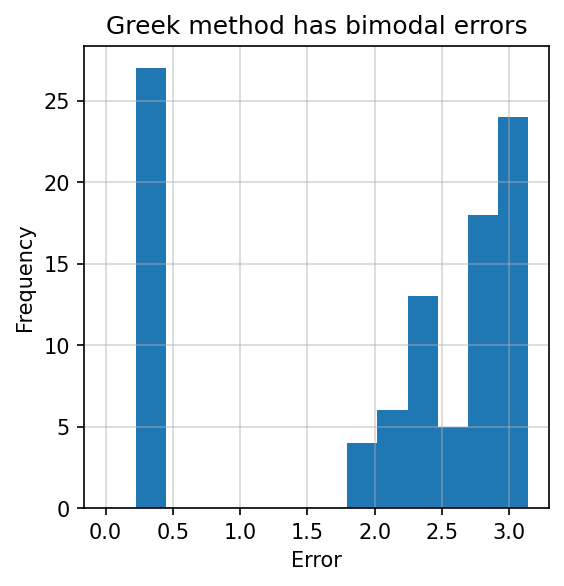

In [31]:
import matplotlib.pyplot as plt 
plt.figure(dpi=150, figsize=(4,4))
plt.title("Greek method has bimodal errors")
plt.hist(results["heraklion"]["errors"], bins=np.linspace(0, np.pi, 15))
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.grid(alpha=.5)


(0.0, 6.283185307179586)

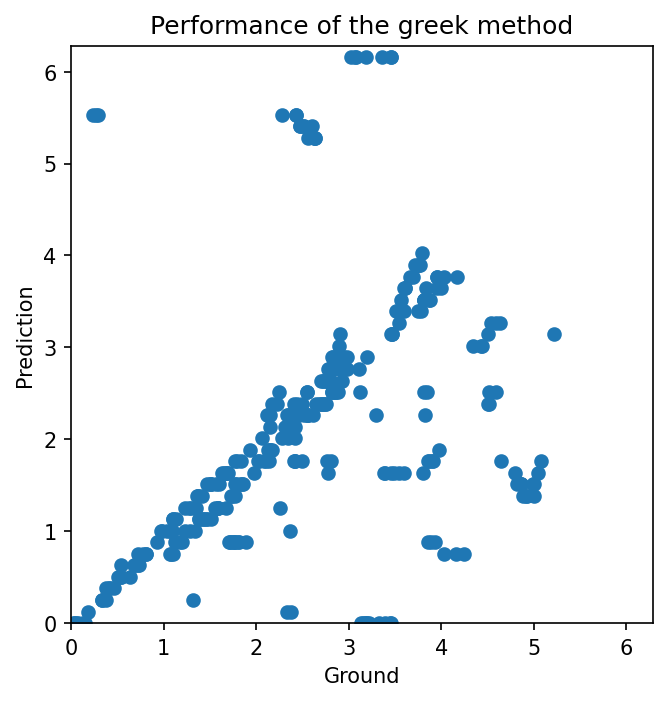

In [45]:
plt.figure(dpi=150, facecolor="white", figsize=(5,5))
plt.scatter(np.concat(results["heraklion"]["grounds"]), np.concat(results["heraklion"]["predictions"]))
plt.xlabel("Ground")
plt.ylabel("Prediction")
plt.title("Performance of the greek method")
plt.xlim(0, 2*np.pi)
plt.ylim(0, 2*np.pi)

(0.0, 6.283185307179586)

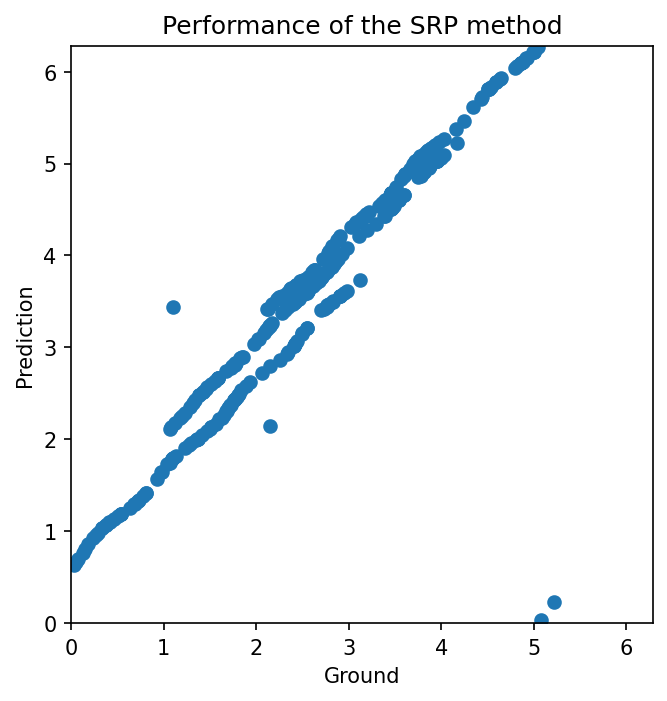

In [49]:
plt.figure(dpi=150, facecolor="white", figsize=(5,5))
plt.scatter(np.concat(results["SRP"]["grounds"]), np.concat(results["SRP"]["predictions"]))
plt.xlabel("Ground")
plt.ylabel("Prediction")
plt.title("Performance of the SRP method")
plt.xlim(0, 2*np.pi)
plt.ylim(0, 2*np.pi)

In [53]:
results_by_spread = {}
for spread in [30, 50, 70, 90]:
    source_doas = [PositionGenerator.fixed_spread_doas(3, spread) for _ in range(100)]
    results = run_benchmark(
        source_doas,
        signals,
        # AnechoicRoomMicrophones.get_microphone_signals,
        signal_generator,
        detectors,
        common_parameters,
    )
    for model in results:
        errors = results[model]["errors"]
        print(f"{model}: {np.mean(errors):.2f} avg, {np.std(errors):.2f} std")
        if model not in results_by_spread:
            results_by_spread[model] = {}
        results_by_spread[model][spread] = f"{np.mean(errors):.2f} avg, {np.std(errors):.2f} std"
results_by_spread

ValueError: Grounds shape ((3,)) does not match preds shape ((4,))

In [5]:
from importlib import reload 
import melatonin.microphones 
reload(melatonin.microphones)
from melatonin.microphones import CustomMicrophoneArray
locations = PositionGenerator.doas_to_positions(
    source_doas, amplitudes=np.array([8])
)
mic_signals = CustomMicrophoneArray.get_microphone_signals(
    locations, signals, common_parameters
)

fft_slices = CustomMicrophoneArray.build_fft_slices(
    mic_signals, common_parameters
)

print("Source locations: ", locations)
print("Signals shape: ", signals.shape)
print("Mic signals shape: ", mic_signals.shape)
print("FFT slices shape: ", fft_slices.shape)


ValueError: operands could not be broadcast together with shapes (100,2,3) (2,) 

In [13]:
import logging 
logging.basicConfig(level="INFO")

In [14]:
(
    detectors[0].freq_bins,
    detectors[0].doa_zone_estimations,
    detectors[0].frequencies_of_interest
)

(array([0.00000000e+00, 2.15332031e+01, 4.30664062e+01, ...,
        2.20069336e+04, 2.20284668e+04, 2.20500000e+04]),
 [np.float64(3.5562562312276067),
  np.float64(3.2443524620185333),
  np.float64(2.0009474538759595),
  np.float64(1.5066462360277468),
  np.float64(0.5154100539378175),
  np.float64(3.8587467188385856),
  np.float64(4.37737001443097),
  np.float64(0.10010773970826341),
  np.float64(2.6000148538103556),
  np.float64(2.187408886903038),
  np.float64(4.593774425889341),
  np.float64(6.2831788375608),
  np.float64(6.283179892207689),
  np.float64(4.290000877281134),
  np.float64(1.2269809598515065),
  np.float64(5.1914067353487034),
  np.float64(6.201579888473023),
  np.float64(6.0634895031002545),
  np.float64(3.703409057853619),
  np.float64(3.661733101977898),
  np.float64(3.042309428906473),
  np.float64(3.002362658850578),
  np.float64(2.836108591038705),
  np.float64(2.8668955411219583),
  np.float64(3.601135298495583),
  np.float64(4.051492675359554),
  np.float64(

In [15]:
import numpy as np
import scipy.optimize

def wrap_angle(angle):
  return (angle+np.pi)%(2*np.pi) - np.pi

def align_predictions(real_doas: np.ndarray, predicted_doas: np.ndarray) -> np.ndarray:
    # Asumimos que vienen en radianes
    D = np.abs(np.array([
      [wrap_angle(real_i - predicted_j) for predicted_j in predicted_doas]
      for real_i in real_doas
    ]))
    print(D)
    row_ind, col_ind = scipy.optimize.linear_sum_assignment(D)
    print(col_ind)
    return (real_doas[row_ind], predicted_doas[col_ind])

real_doas_d = np.array([179, 359, 30])
predicted_doas_d = np.array([0, 180, 30])
real_doas, predicted_doas = np.deg2rad(real_doas_d), np.deg2rad(predicted_doas_d)
np.rad2deg(align_predictions(real_doas, predicted_doas))


[[3.12413936 0.01745329 2.60054059]
 [0.01745329 3.12413936 0.54105207]
 [0.52359878 2.61799388 0.        ]]
[1 0 2]


array([[179., 359.,  30.],
       [180.,   0.,  30.]])